## Tensorflow ANN Model for A_Z Handwrittern Dataset

## Importing all the required Libraries

In [1]:
import tensorflow as tf # Import TensorFlow for building and training the Artificial Neural Network

# Import libraries for data manipulation
import pandas as pd
import numpy as np

# Import libraries for data visualization
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split # Import utility for splitting the dataset into training and testing sets
from sklearn.metrics import classification_report, confusion_matrix # Import evaluation metrics

print(tf.__version__) # Display the installed TensorFlow version

2.21.0


## Data Preprocessing

In [2]:
# A_Z Handwritten dataset parameters
num_classes = 26 # total classes (26 alphabets)
num_features = 784 # data features (img shape: 28*28)

# loading kaggle A_Z Handwritten dataset csv file.
# Updating the path of 'A_Z Handwritten Data.csv' file is located
csv_path = "A_Z Handwritten Data.csv" 
dataset = pd.read_csv(csv_path).astype('float32')

# Extracting labels and features
# The first column contains the labels (0 to 25); the remaining 784 columns are pixels
x = dataset.iloc[:,1:].values
y = dataset.iloc[:,0].values

# Splitting dataset into Training(80%) & Testing(20%)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.20, random_state = 42)

# Normalizing pixel values
x_train = x_train / 255.0
x_test = x_test / 255.0

# Ensure data types are float32 and int64 respectively
y_train, y_test = y_train.astype(np.int64), y_test.astype(np.int64)

## Visualizing the Training Images
Each image is represented as a 784-dimensional vector (28 × 28 pixels), and the labels range from 0 to 25, corresponding to the letters A–Z. The following function visualizes random training images to better understand the input data before training the neural network.

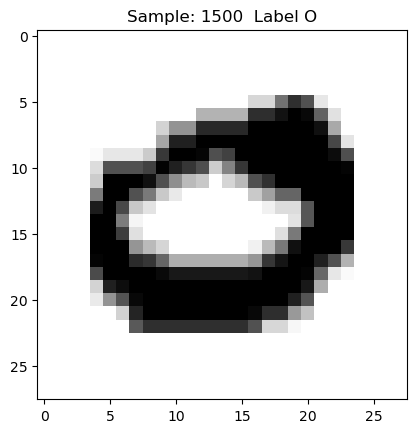

In [3]:
# Importing plotting library
%matplotlib inline
import matplotlib.pyplot as plt

# Mapping dictionary from integer class to character label
alphabet_mapping = {i: chr(65 + i) for i in range(26)} # 0 -> 'A', 1 -> 'B', etc.

def display_sample(num):    # Function to display a sample handwritten alphabet image 
    
    label_idx = y_train[num] # Get the numeric label of the selected image
    label_char = alphabet_mapping.get(label_idx, f"Unknown ({label_idx})")  # Converting the numeric label to its corresponding alphabet letter
    
    # Reshaping the flattened image (784 pixels) back to its original 28 × 28 format
    image = x_train[num].reshape([28,28])
    plt.title('Sample: %d  Label %s' % (num, label_char)) # Display the image with its corresponding alphabet label
    plt.imshow(image, cmap=plt.get_cmap('gray_r'))
    plt.show()
    
display_sample(1500) # Display a sample image from the training dataset

Here, we can see the label for a selected training image and also visualize what that handwritten alphabet sample looks like. Some letters may be difficult to classify because handwriting styles can vary a lot.

## Visualizing the Flattened Training Dataset

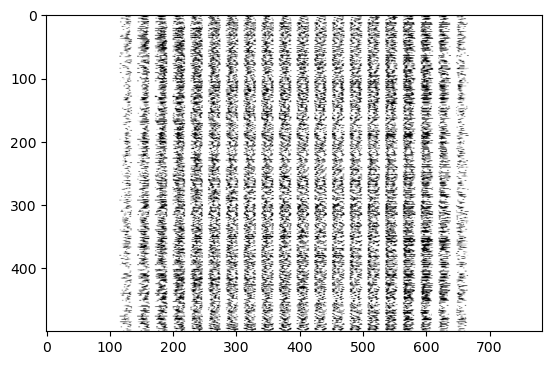

In [4]:
images = x_train[0].reshape([1,784]) # Reshape the first training image into a 1 × 784 vector

# Combining the next 499 flattened training images into one array
for i in range(1, 500):
    images = np.concatenate((images, x_train[i].reshape([1,784])))
    
# Display the combined visualization of the flattened training images    
plt.imshow(images, cmap=plt.get_cmap('gray_r'))
plt.show()

## Setting Training Parameters and Building the Neural Network

In [5]:
# Training parameters.
learning_rate = 0.001
training_steps = 5000 # Increased training_steps from 3000 to 5000
batch_size = 128 # Reduced batch size from 250 to 128
display_step = 100 # Display training progress every 100 steps

# Network parameters.
n_hidden_1 = 512 # 1st layer Number of neurons.
n_hidden_2 = 256 # 2nd layer Number of neurons.

In [6]:
# Use tf.data API to shuffle and batch data.
train_data = tf.data.Dataset.from_tensor_slices((x_train, y_train)) # Create a TensorFlow dataset from the training data
train_data = train_data.repeat().shuffle(5000).batch(batch_size).prefetch(1) # Shuffle, batch, repeat, and prefetch the training data for efficient learning

## Initializing the Neural Network Parameters

In [7]:
# Initializing the weights and biases for each layer of the neural network

# A random value generator to initialize weights initially
random_normal = tf.initializers.RandomNormal()

weights = {
    'h1': tf.Variable(random_normal([num_features, n_hidden_1])),
    'h2': tf.Variable(random_normal([n_hidden_1, n_hidden_2])),
    'out': tf.Variable(random_normal([n_hidden_2, num_classes])) # [256, 26]
}
biases = {
    'b1': tf.Variable(tf.zeros([n_hidden_1])),
    'b2': tf.Variable(tf.zeros([n_hidden_2])),
    'out': tf.Variable(tf.zeros([num_classes])) # [26]
}

## Creating the TensorFlow Neural Network Model
Creating complete neural network structure, including the input layer, hidden layers, and output layer used for A-Z handwritten alphabet classification.

In [8]:
# Create model.
def neural_net(inputData):
    # Hidden fully connected layer with 512 neurons.
    hidden_layer1 = tf.add(tf.matmul(inputData, weights['h1']), biases['b1'])
    # Apply ReLU to hidden_layer output for non-linearity.
    hidden_layer1 = tf.nn.relu(hidden_layer1)
    # Hidden fully connected layer with 256 neurons.
    hidden_layer2 = tf.add(tf.matmul(hidden_layer1, weights['h2']), biases['b2'])
    # Apply ReLU to hidden_layer output for non-linearity.
    hidden_layer2 = tf.nn.relu(hidden_layer2)
    
    # Output fully connected layer with a neuron for each class.
    out_layer = tf.matmul(hidden_layer2, weights['out']) + biases['out']
    # Apply softmax to normalize the logits to a probability distribution.
    return (out_layer)

## Defining the Loss Function

In [9]:
def cross_entropy(y_pred, y_true):
    #Converting labels to int64 required by sparse categorical operations
    y_true = tf.cast(y_true, tf.int64)
    # Compute cross-entropy natively using raw logits (y_pred)
    loss = tf.nn.sparse_softmax_cross_entropy_with_logits(labels=y_true, logits=y_pred)
    # Average the loss across the training batch
    return tf.reduce_mean(loss)

## Defining the Optimizer and Training Function
The optimizer is responsible for updating the neural network's weights and biases to minimize the loss function. In this implementation, the Adam optimizer is used because it provides faster and more stable convergence than standard Stochastic Gradient Descent (SGD). The training function performs one optimization step by computing the loss, calculating the gradients, and updating the trainable parameters of the network.

In [10]:
optimizer = tf.optimizers.Adam(learning_rate = 0.001) # Replaced standard low-level SGD optimizer with Adam Optimizer

def run_optimization(x, y):
    # Wrap computation inside a GradientTape for automatic differentiation.
    with tf.GradientTape() as g:
        pred = neural_net(x)
        loss = cross_entropy(pred, y)
        
    # Variables to update, i.e. trainable variables.
    trainable_variables = list(weights.values()) + list(biases.values())

    # Compute gradients.
    gradients = g.gradient(loss, trainable_variables)
    
    # Update W and b following gradients.
    optimizer.apply_gradients(zip(gradients, trainable_variables))

## Defining the Model Accuracy

In [11]:
# Accuracy metric.
def accuracy(y_pred, y_true):
    # Predicted class is the index of highest score in prediction vector (i.e. argmax).
    correct_prediction = tf.equal(tf.argmax(y_pred, 1), tf.cast(y_true, tf.int64))
    return tf.reduce_mean(tf.cast(correct_prediction, tf.float32), axis=-1)

## Training the Artificial Neural Network

In [12]:
# Run training for the given number of steps.
for step, (batch_x, batch_y) in enumerate(train_data.take(training_steps), 1):
    # Run the optimization to update W and b values.
    run_optimization(batch_x, batch_y)
    
    if step % display_step == 0:
        pred = neural_net(batch_x)
        loss = cross_entropy(pred, batch_y)
        acc = accuracy(pred, batch_y)
        print("Training epoch: %i, Loss: %f, Accuracy: %f" % (step, loss, acc))

Training epoch: 100, Loss: 0.477322, Accuracy: 0.875000
Training epoch: 200, Loss: 0.311801, Accuracy: 0.937500
Training epoch: 300, Loss: 0.180675, Accuracy: 0.953125
Training epoch: 400, Loss: 0.279389, Accuracy: 0.929688
Training epoch: 500, Loss: 0.195487, Accuracy: 0.953125
Training epoch: 600, Loss: 0.113695, Accuracy: 0.968750
Training epoch: 700, Loss: 0.112864, Accuracy: 0.976562
Training epoch: 800, Loss: 0.161664, Accuracy: 0.945312
Training epoch: 900, Loss: 0.187351, Accuracy: 0.945312
Training epoch: 1000, Loss: 0.175566, Accuracy: 0.960938
Training epoch: 1100, Loss: 0.210173, Accuracy: 0.953125
Training epoch: 1200, Loss: 0.145619, Accuracy: 0.953125
Training epoch: 1300, Loss: 0.228729, Accuracy: 0.945312
Training epoch: 1400, Loss: 0.084073, Accuracy: 0.976562
Training epoch: 1500, Loss: 0.091956, Accuracy: 0.968750
Training epoch: 1600, Loss: 0.108977, Accuracy: 0.984375
Training epoch: 1700, Loss: 0.058890, Accuracy: 0.984375
Training epoch: 1800, Loss: 0.094967, Ac

## Evaluating the Trained Model

In [13]:
# Test model on validation set.
pred = neural_net(x_test)
print("Test Accuracy: %f" % accuracy(pred, y_test))

Test Accuracy: 0.980615


## Classification report and Confusion Matrix.

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      2806
           1       0.96      0.98      0.97      1673
           2       0.98      0.99      0.99      4742
           3       0.94      0.96      0.95      2044
           4       0.99      0.96      0.98      2214
           5       0.97      0.97      0.97       231
           6       0.96      0.95      0.96      1183
           7       0.94      0.95      0.95      1466
           8       0.97      0.98      0.97       237
           9       0.95      0.98      0.97      1668
          10       0.97      0.94      0.96      1132
          11       0.99      0.98      0.98      2319
          12       0.98      0.98      0.98      2487
          13       0.97      0.98      0.97      3756
          14       0.99      0.99      0.99     11629
          15       0.99      0.98      0.98      3868
          16       0.95      0.96      0.96      1159
    

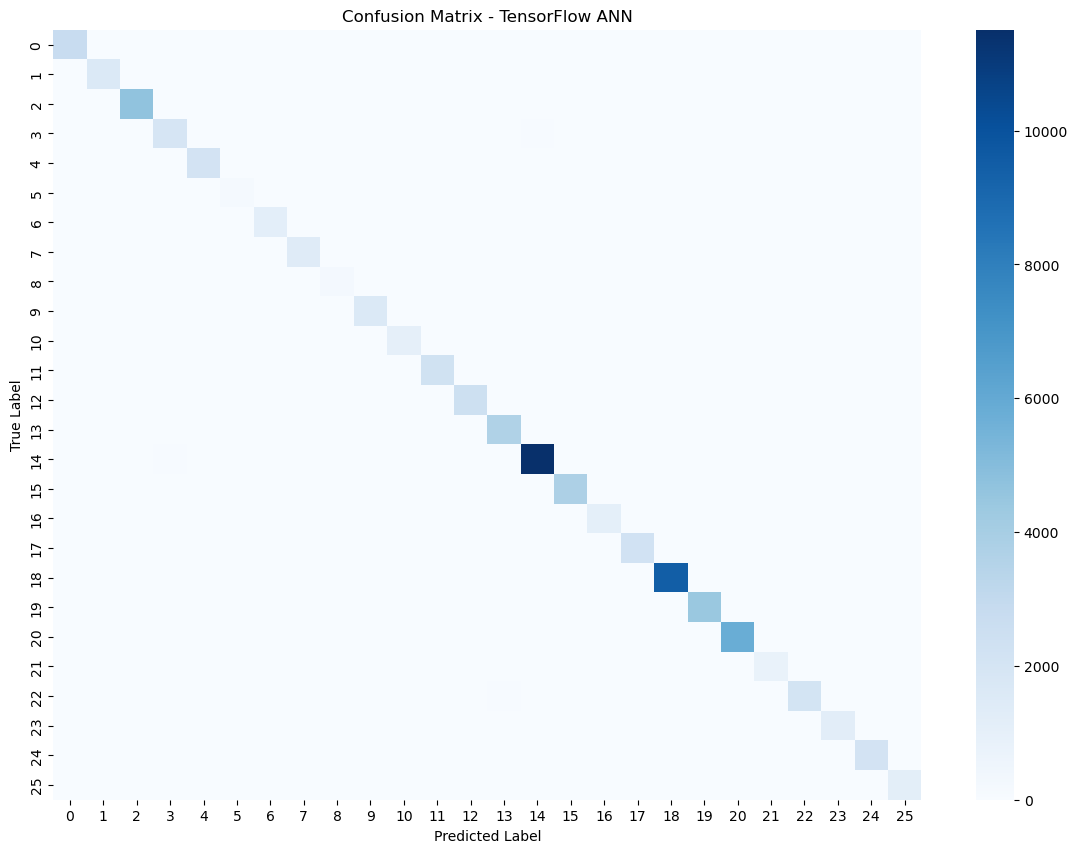

In [14]:
# Predict classes
y_pred = neural_net(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# True labels (already integer labels, not one-hot encoded)
y_true = y_test

# Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred_classes))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(14, 10))
sns.heatmap(cm, annot=False, cmap="Blues")
plt.title("Confusion Matrix - TensorFlow ANN")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## Results

The TensorFlow Artificial Neural Network (ANN) is successfully trained and evaluated on the A–Z Handwritten Alphabet dataset. 

1. Model achieved an overall **test accuracy of approximately 98%**.
2. The classification report shows high precision, recall, and F1-scores for most alphabet classes, indicating consistent performance across all 26 classes. 
3. The confusion matrix confirms that the majority of predictions lie along the main diagonal, with only a few misclassifications between visually similar handwritten letters.

Overall, the results shows that the TensorFlow ANN model is effective for handwritten alphabet recognition and provides reliable classification performance on unseen test data.

## Visualizing some misclassified model predictions

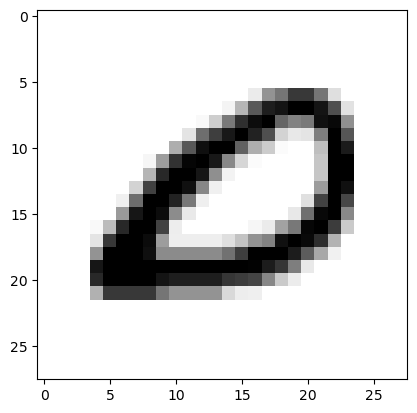

Original Labels: O
Model prediction: D


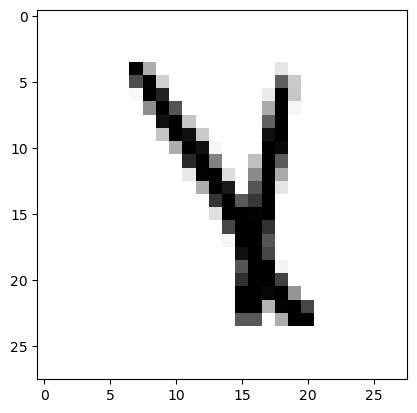

Original Labels: X
Model prediction: Y


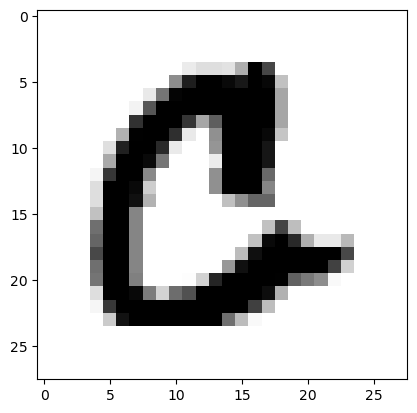

Original Labels: G
Model prediction: C


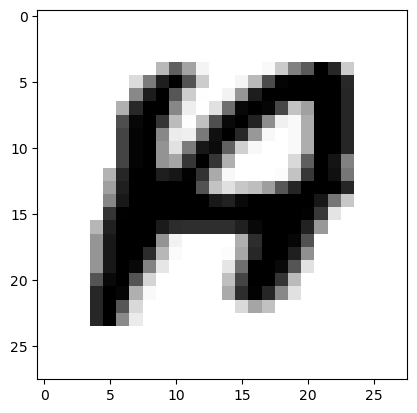

Original Labels: A
Model prediction: H


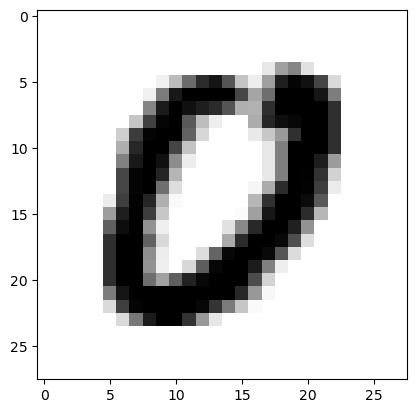

Original Labels: O
Model prediction: U


In [15]:
n_images = 300 # Number of test images to examine

# Selecting the first 300 images and their corresponding labels from the test dataset
test_images = x_test[:n_images]
test_labels = y_test[:n_images]
predictions = neural_net(test_images) # Generating predictions for the selected test images

# Display only the incorrectly classified images
for i in range(n_images):
    model_prediction = np.argmax(predictions.numpy()[i])
    if (model_prediction != test_labels[i]):
        plt.imshow(np.reshape(test_images[i], [28, 28]), cmap='gray_r') # Display the misclassified handwritten alphabet image
        plt.show()
        # Print the actual and predicted alphabet labels
        print("Original Labels: %s" % alphabet_mapping[test_labels[i]])
        print("Model prediction: %s" % alphabet_mapping[model_prediction])

## Conclusion
The model correctly classified the majority of the handwritten alphabet images in the test dataset. Only a small number of samples were misclassified, typically involving letters with similar handwritten shapes. Visualizing these misclassified examples provides insight into the model's limitations and helps identify cases where handwriting ambiguity affects prediction accuracy. Overall, the results demonstrate that the TensorFlow ANN is effective for handwritten alphabet recognition.